<a href="https://colab.research.google.com/github/KutyshenkoYana/ITStep-AI/blob/superwised_learning/SL_PracticalWork_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Дані

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/ITStep-AI/refs/heads/superwised_learning/data/car_price.csv")

In [3]:
df.head()

,mileage,age,engine,horsepower,num_previous_owners,price
0,60675,4,1.6,228,1,18421
1,23671,24,1.7,179,1,11279
2,82893,5,2.3,115,1,10279
3,94692,11,2.4,94,1,9876
4,12509,9,1.8,126,0,19428


# Опис даних

- **mileage** — пробіг автомобіля в кілометрах
- **age** — вік автомобіля в роках
- **engine** — об'єм двигуна автомобіля в літрах
- **horsepower** — потужність двигуна в кінських силах
- **num_previous_owners** — кількість попередніх власників автомобіля
- **price** — ціна автомобіля

Потрібно спрогнозувати **ціну** автомобіля

# Завдання 1
Розділіть дані на ознаки для моделі(Х) та цільову змінну(y)

In [4]:
X = df.drop(columns=["price"])
y = df["price"]

# Завдання 2
Розділіть дані на тренувальну та тестову вибірку

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Завдання 3
Нетренуйте дерево рішень на тренувальній вибірці

При створенні моделі використовуйте параметри за замовчуванням

In [6]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(X_train, y_train)

DecisionTreeRegressor()

# Завдання 4
Спронозуйте ціну автомобіля для тренувальних даних та порівняйте зі справжніми

Використайте метрики MAE, MSE, R2

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_train_pred = model.predict(X_train)

print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("MSE:", mean_squared_error(y_train, y_train_pred))
print("R2:", r2_score(y_train, y_train_pred))

MAE: 0.0
MSE: 0.0
R2: 1.0


# Завдання 5
Спронозуйте ціну автомобіля для тестових даних та порівняйте зі справжніми

Використайте метрики MAE, MSE, R2

In [8]:
y_test_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("MSE:", mean_squared_error(y_test, y_test_pred))
print("R2:", r2_score(y_test, y_test_pred))

MAE: 3005.547268907563
MSE: 14398422.414915966
R2: 0.5378304351534975


# Завдання 6
Для різних значень параметра `max_depth` натренуйте модель та порахуйте метрику `MAE` на тренувальних та тестових даних

Отримайте відповідно 2 списки -- `train_mae` та `test_mae`
візуалізуйте їх

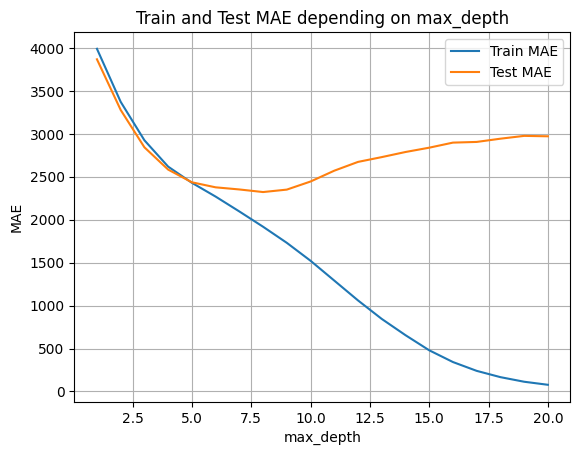

In [11]:
import matplotlib.pyplot as plt

max_depths = range(1, 21)
train_mae = []
test_mae = []

for depth in max_depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_mae.append(mean_absolute_error(y_train, train_pred))
    test_mae.append(mean_absolute_error(y_test, test_pred))

plt.plot(max_depths, train_mae, label="Train MAE")
plt.plot(max_depths, test_mae, label="Test MAE")

plt.xlabel("max_depth")
plt.ylabel("MAE")
plt.title("Train and Test MAE depending on max_depth")
plt.legend()
plt.grid()

plt.show()

In [ ]:
# код для візуалізації
# вам потрібно створити список max_depthes зі значеннями параметра який ви використовували
import matplotlib.pyplot as plt

plt.plot(max_depths, train_mae, label="Train MAE")
plt.plot(max_depths, test_mae, label="Test MAE")

plt.xlabel("max_depth")
plt.ylabel("MAE")
plt.title("Train and Test MAE depending on max_depth")
plt.legend()
plt.grid()

plt.show()

# Завдання 7
По графіку визначте оптимальне значення параметра `max_depth`

In [12]:
optimal_depth = max_depths[test_mae.index(min(test_mae))]
print("Optimal max_depth:", optimal_depth)

Optimal max_depth: 8


# Завдання 8
Побудуйте такіж графіки для метрик MSE та R2

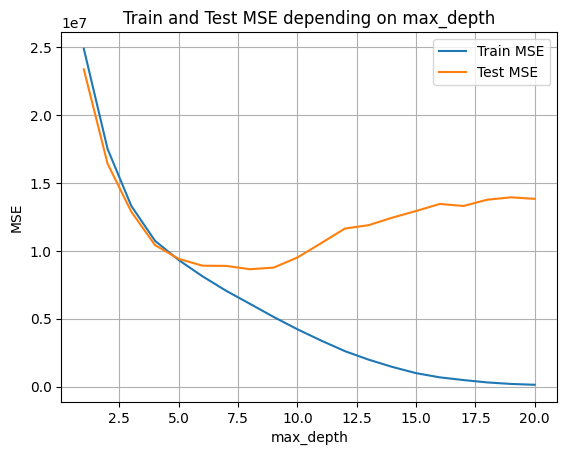

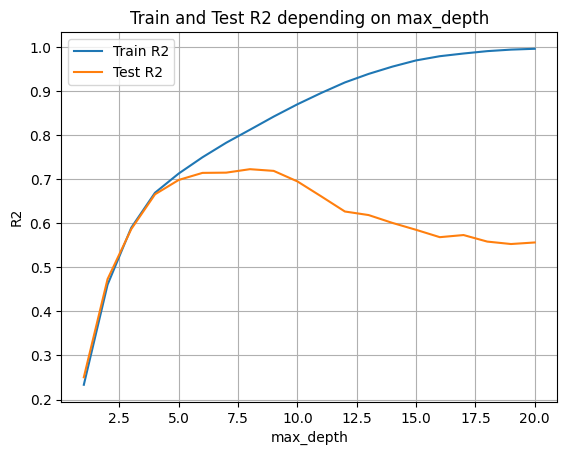

In [13]:
train_mse = []
test_mse = []
train_r2 = []
test_r2 = []

for depth in max_depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_mse.append(mean_squared_error(y_train, train_pred))
    test_mse.append(mean_squared_error(y_test, test_pred))

    train_r2.append(r2_score(y_train, train_pred))
    test_r2.append(r2_score(y_test, test_pred))

plt.plot(max_depths, train_mse, label="Train MSE")
plt.plot(max_depths, test_mse, label="Test MSE")
plt.xlabel("max_depth")
plt.ylabel("MSE")
plt.title("Train and Test MSE depending on max_depth")
plt.legend()
plt.grid()
plt.show()

plt.plot(max_depths, train_r2, label="Train R2")
plt.plot(max_depths, test_r2, label="Test R2")
plt.xlabel("max_depth")
plt.ylabel("R2")
plt.title("Train and Test R2 depending on max_depth")
plt.legend()
plt.grid()
plt.show()